# All Models Analyzis

In [1]:
import pandas as pd

from benchmark_lib import DATA_DIR

frames = []
for csv in sorted(DATA_DIR.glob("*/*/benchmark.csv")):
  runs = pd.read_csv(csv)
  runs.insert(0, "vendor", csv.parent.parent.name)
  runs.insert(1, "benchmark", csv.parent.name)
  frames.append(runs)

benchmarks = pd.concat(frames, ignore_index=True)
benchmarks["start_time"] = pd.to_datetime(benchmarks["start_time"], format="mixed")
benchmarks.groupby(["vendor", "benchmark"]).agg(
  runs=("run", "size"), tasks=("task", "nunique"), model=("model", "first"), hardware=("hardware", "first")
)


runs  tasks  \
vendor    benchmark                                     
alibaba   qwen-3.6-35b                     142     15   
          qwen-3.6-35b-m5max               111      8   
anthropic claude-opus-5                    250     25   
deepseek  deepseek-v4-flash                 81      8   
google    gemma-4-26b-a4b                   83      8   
          gemma-4-31b                       82      8   
meta      muse-glimmer-30b                  70      7   
          muse-glimmer-30b-m5max            80      8   
minimax   minimax-m2.7                      80      8   
nvidia    nemotron-3.5-lightning-30b-a3b    90      8   
openai    gpt-5.6-terra                    250     25   
          gpt-oss-120b                      84      8   

                                                                           model  \
vendor    benchmark                                                                
alibaba   qwen-3.6-35b                      unsloth/Qwen3.6-35B-A3B-GGUF:Q4_K_XL   
          qwen-3.6-35b-m5max                          Qwen3.6-35B-A3B-UD-Q4_K_XL   
anthropic claude-opus-5                                            claude-opus-5   
deepseek  deepseek-v4-flash                         DeepSeek-V4-Flash-0731-IQ2_M   
google    gemma-4-26b-a4b                                gemma-4-26B-A4B-Q4_K_XL   
          gemma-4-31b                                        gemma-4-31B-Q4_K_XL   
meta      muse-glimmer-30b                              Muse-Glimmer-30B-Q4_K_XL   
          muse-glimmer-30b-m5max                        Muse-Glimmer-30B-Q4_K_XL   
minimax   minimax-m2.7                                    MiniMax-M2.7-UD-Q3_K_S   
nvidia    nemotron-3.5-lightning-30b-a3b  Nemotron-3.5-Lightning-30B-A3B-Q4_K_XL   
openai    gpt-5.6-terra                                            gpt-5.6-terra   
          gpt-oss-120b                                        gpt-oss-120b-MXFP4   

                                                               hardware  
vendor    benchmark                                                      
alibaba   qwen-3.6-35b                    NVIDIA GeForce RTX 4070 SUPER  
          qwen-3.6-35b-m5max                         Apple M5 Max 128GB  
anthropic claude-opus-5                                           cloud  
deepseek  deepseek-v4-flash                          Apple M5 Max 128GB  
google    gemma-4-26b-a4b                            Apple M5 Max 128GB  
          gemma-4-31b                                Apple M5 Max 128GB  
meta      muse-glimmer-30b                            Apple M3 Max 36GB  
          muse-glimmer-30b-m5max                     Apple M5 Max 128GB  
minimax   minimax-m2.7                               Apple M5 Max 128GB  
nvidia    nemotron-3.5-lightning-30b-a3b             Apple M5 Max 128GB  
openai    gpt-5.6-terra                                           cloud  
          gpt-oss-120b                               Apple M5 Max 128GB

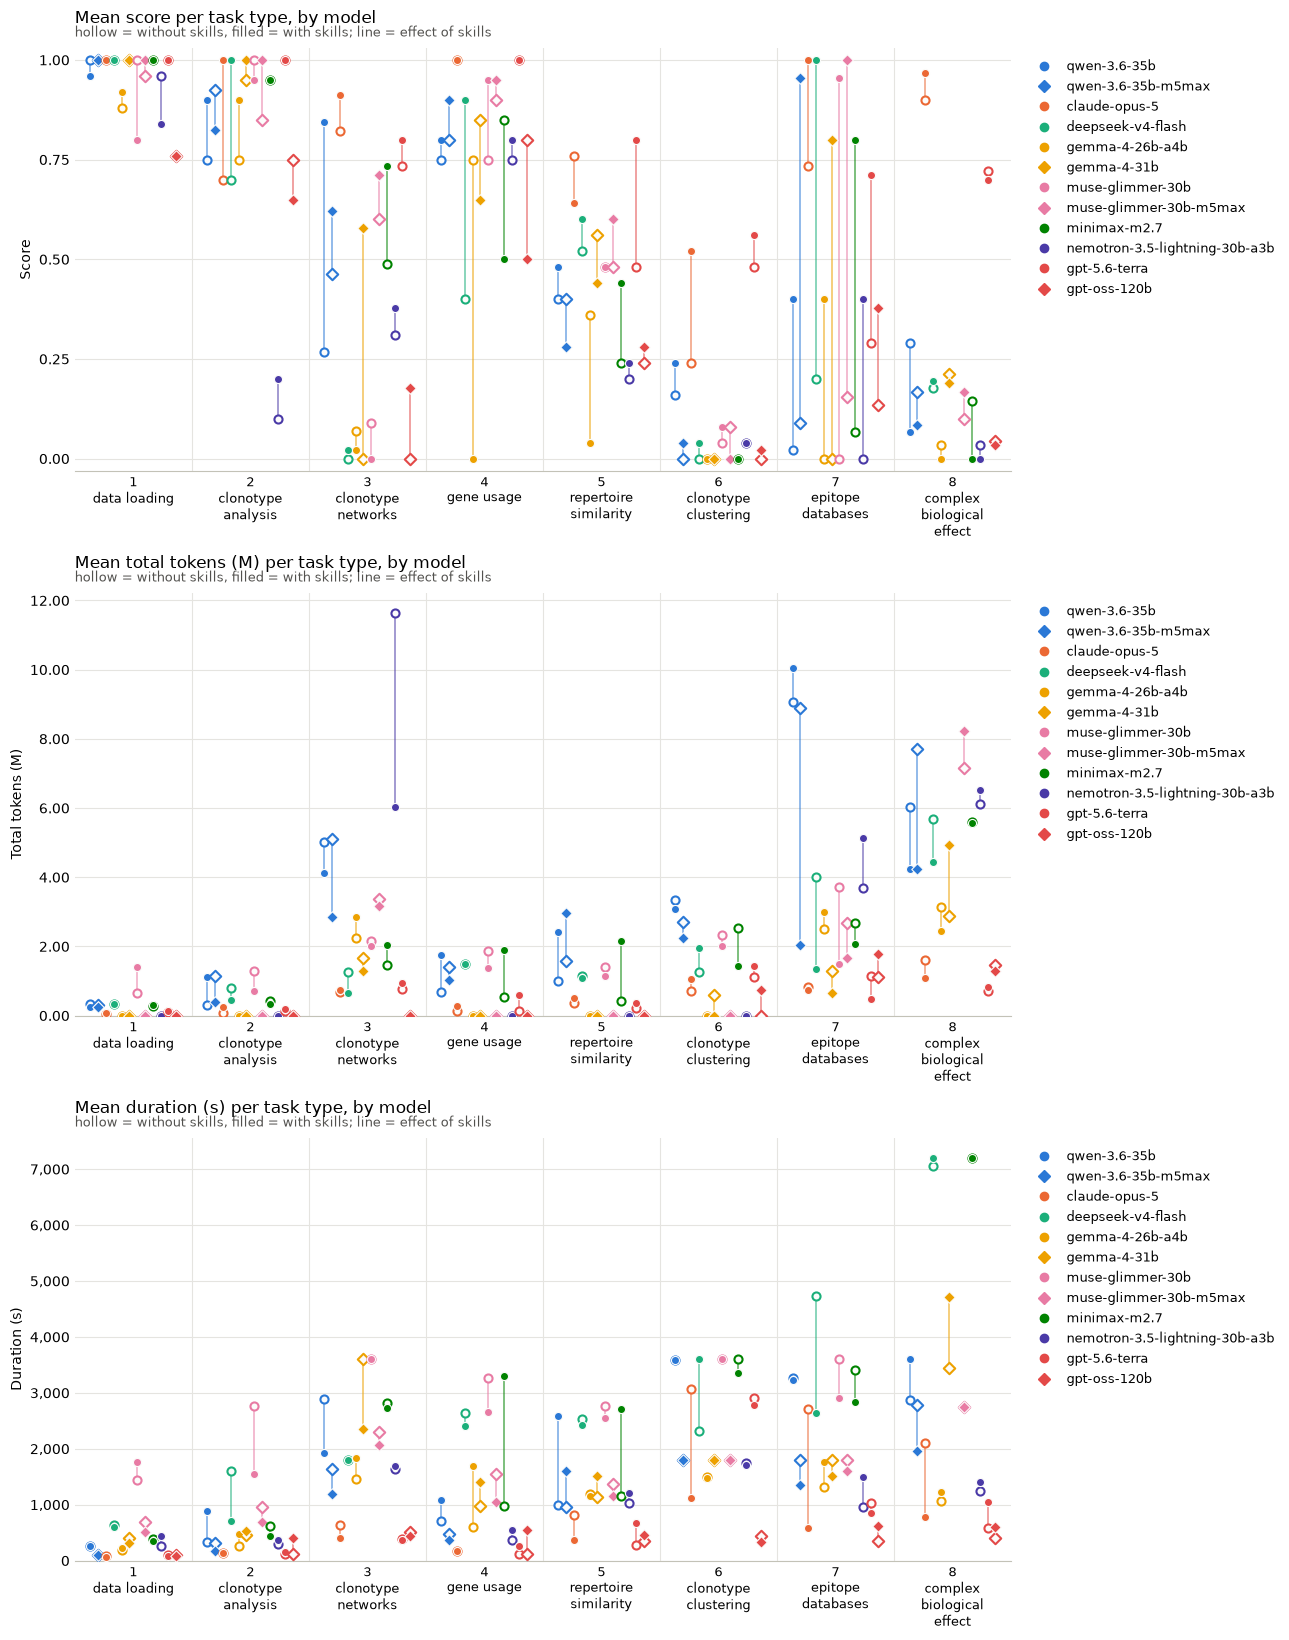

In [2]:
from matplotlib import pyplot as plt

from benchmark_lib import drop_sparse_tasks, plot_models_by_task_type

scirpy = drop_sparse_tasks(benchmarks[benchmarks["kit"] == "scirpy"], min_runs=3)

fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(13, 5.5 * 3))
means = {
  column: plot_models_by_task_type(scirpy, column=column, ax=ax)
  for column, ax in zip(["score", "total_tokens", "duration_seconds"], axs)
}
fig.tight_layout()
plt.show()


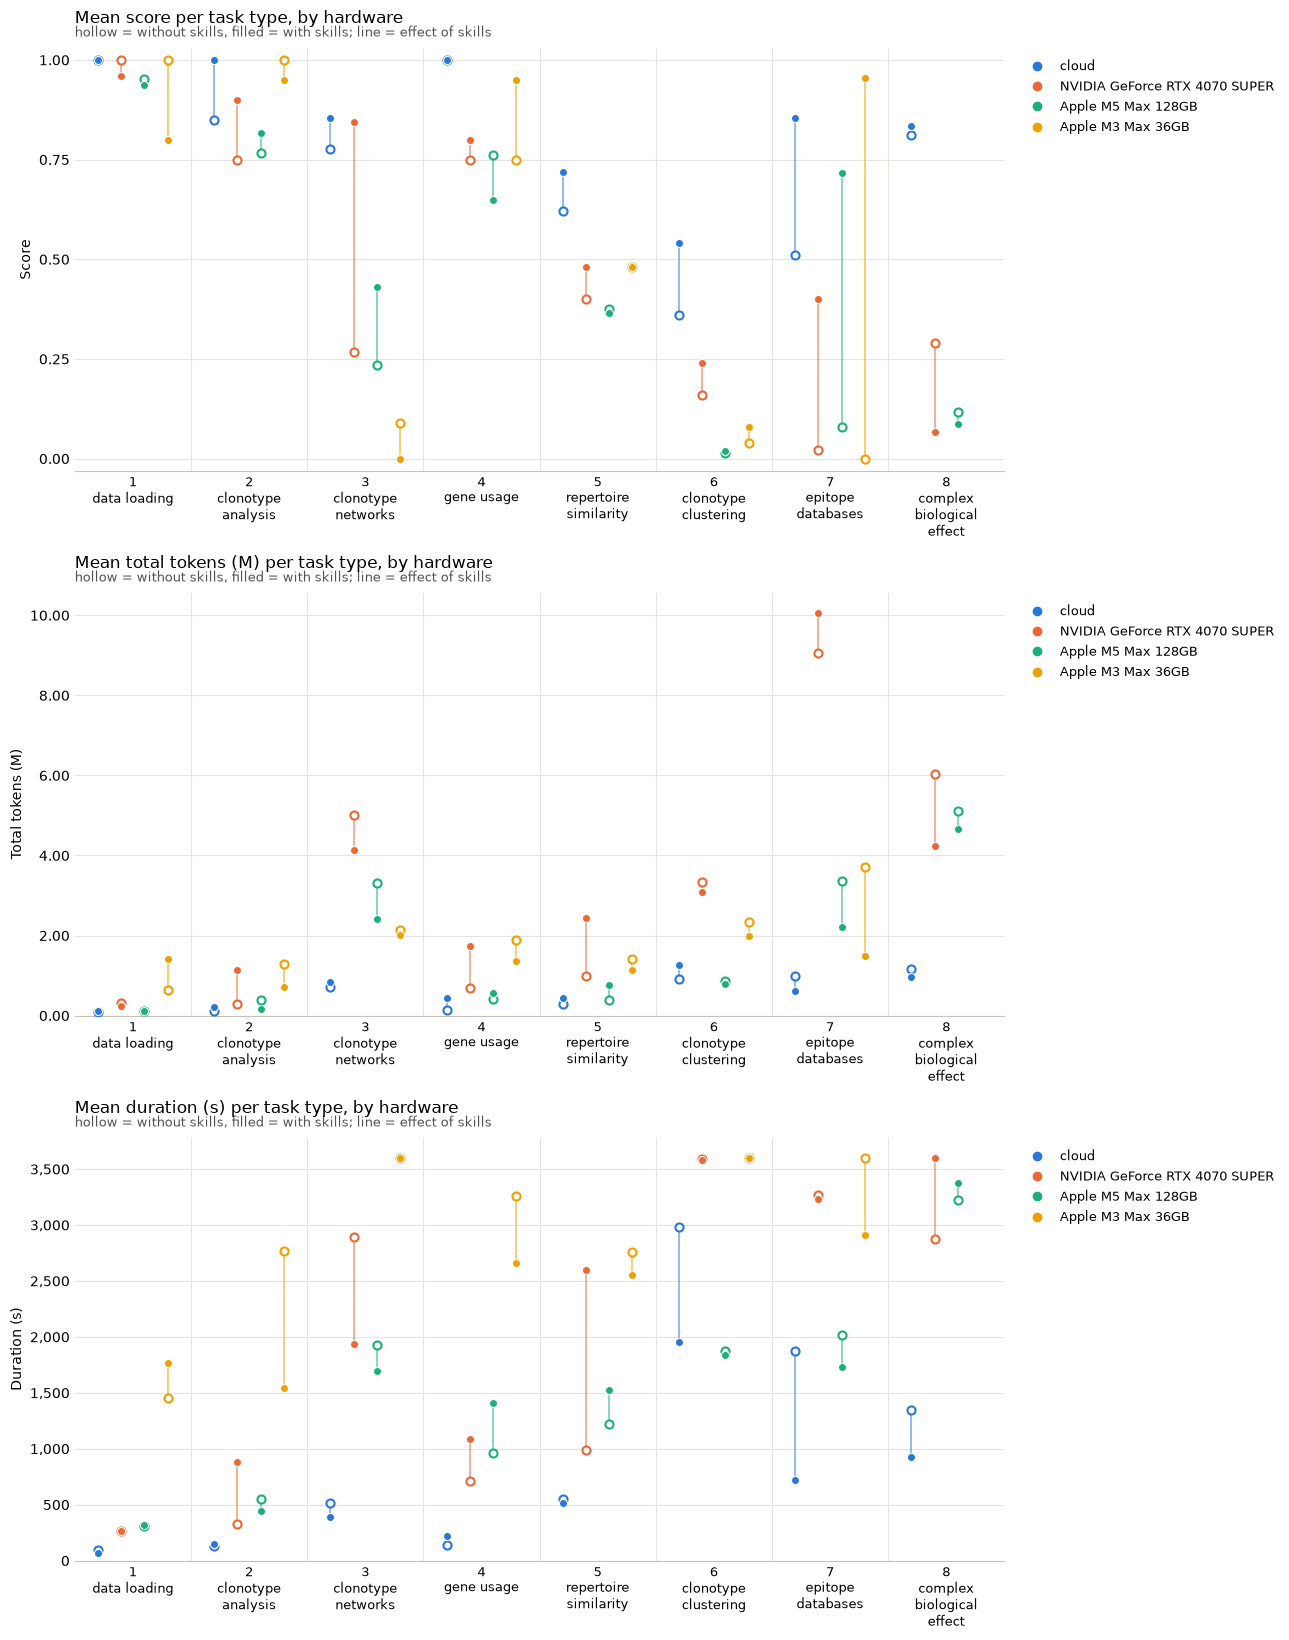

In [3]:
fig, axs = plt.subplots(nrows=3, ncols=1, figsize=(13, 5.5 * 3))
hardware_means = {
  column: plot_models_by_task_type(scirpy, column=column, ax=ax, by="hardware")
  for column, ax in zip(["score", "total_tokens", "duration_seconds"], axs)
}
fig.tight_layout()
plt.show()


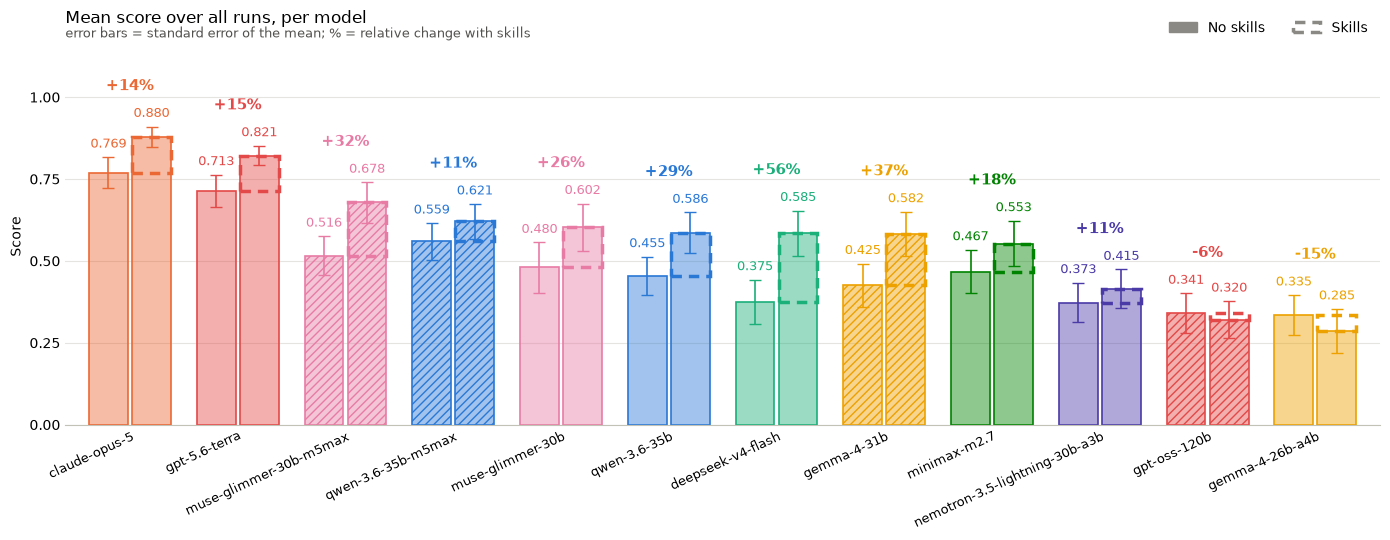

In [4]:
from benchmark_lib import plot_total_score

fig, ax = plt.subplots(figsize=(14, 5.5))
total_by_model = plot_total_score(scirpy, by="benchmark", ax=ax)
fig.tight_layout()
plt.show()


14 tasks run by all three: 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13, 14


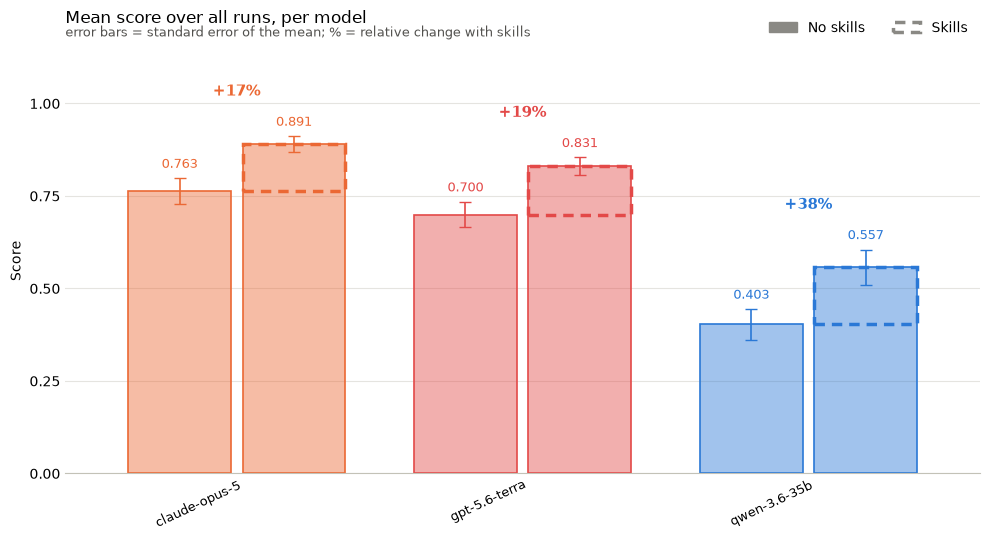

In [8]:
top_models = drop_sparse_tasks(
  benchmarks[benchmarks["benchmark"].isin(["gpt-5.6-terra", "claude-opus-5", "qwen-3.6-35b"])], min_runs=3
)
common_tasks = set.intersection(*top_models.groupby("benchmark")["task"].apply(set))
top_models = top_models[top_models["task"].isin(common_tasks)]
print(f"{len(common_tasks)} tasks run by all three: {', '.join(sorted(t.split('-')[0] for t in common_tasks))}")

fig, ax = plt.subplots(figsize=(10, 5.5))
total_top_models = plot_total_score(top_models, by="benchmark", ax=ax)
fig.tight_layout()
plt.show()


25 tasks run by both: 01, 02, 03, 04, 05, 06, 07, 08, 09, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25


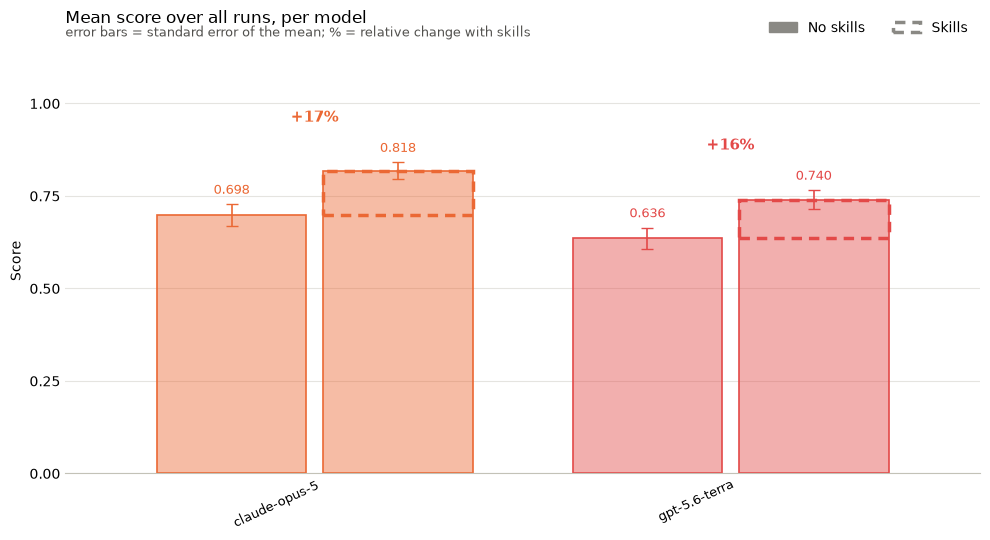

In [9]:
top_models = drop_sparse_tasks(
  benchmarks[benchmarks["benchmark"].isin(["gpt-5.6-terra", "claude-opus-5"])], min_runs=3
)
common_tasks = set.intersection(*top_models.groupby("benchmark")["task"].apply(set))
top_models = top_models[top_models["task"].isin(common_tasks)]
print(f"{len(common_tasks)} tasks run by both: {', '.join(sorted(t.split('-')[0] for t in common_tasks))}")

fig, ax = plt.subplots(figsize=(10, 5.5))
total_top_models = plot_total_score(top_models, by="benchmark", ax=ax)
fig.tight_layout()
plt.show()
